In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sys
import os

from openradar.mmwave.dataloader.adc import DCA1000
from openradar.mmwave.dsp.range_processing import range_processing
from openradar.mmwave.dsp.doppler_processing import doppler_processing
from openradar.mmwave.dsp.utils import Window

In [3]:
DATA_PATH="../data/Mobile_data/adc_data_2026-06-03_15-52-17_pho_static.npy"

# Configurations

In [4]:
numFrames = 200
numADCSamples = 256
numTxAntennas = 3
numRxAntennas = 4
numLoopsPerFrame = 182
numChirpsPerFrame = numTxAntennas * numLoopsPerFrame

# C                 = 3e8
# START_FREQ        = 77e9          
# FREQ_SLOPE        = 60.012e12      
# ADC_SAMPLE_RATE   = 4400e3         
# ADC_START_TIME    = 6e-6           
# IDLE_TIME         = 7e-6           
# RAMP_END_TIME     = 65e-6          
# RX_GAIN           = 30   

In [5]:
# ADC_DURATION    = NUM_ADC_SAMPLES / ADC_SAMPLE_RATE        
# CHIRP_TIME      = IDLE_TIME + RAMP_END_TIME                  
# BW              = FREQ_SLOPE * ADC_DURATION                 
# range_res       = C / (2 * BW)                               
# max_range       = range_res * NUM_ADC_SAMPLES / 2            
# lam             = C / START_FREQ                             
# vel_res         = lam / (2 * CHIRP_TIME * NUM_LOOPS)     
# max_vel         = vel_res * NUM_LOOPS / 2                    
# num_virt_ant    = NUM_TX * NUM_RX 

# Data Loading

In [6]:
adc_data = np.load(DATA_PATH)
print("Raw data shape : " , adc_data.shape)

adc_data = np.apply_along_axis(DCA1000.organize, 1, adc_data,num_chirps=numChirpsPerFrame,num_rx=numRxAntennas, num_samples=numADCSamples)
print("Reshaped data shape: ", adc_data.shape)

Raw data shape :  (600, 1118208)
Reshaped data shape:  (600, 546, 4, 256)


# Range FFT

In [7]:
radar_cubes = np.array([range_processing(frame) for frame in adc_data])

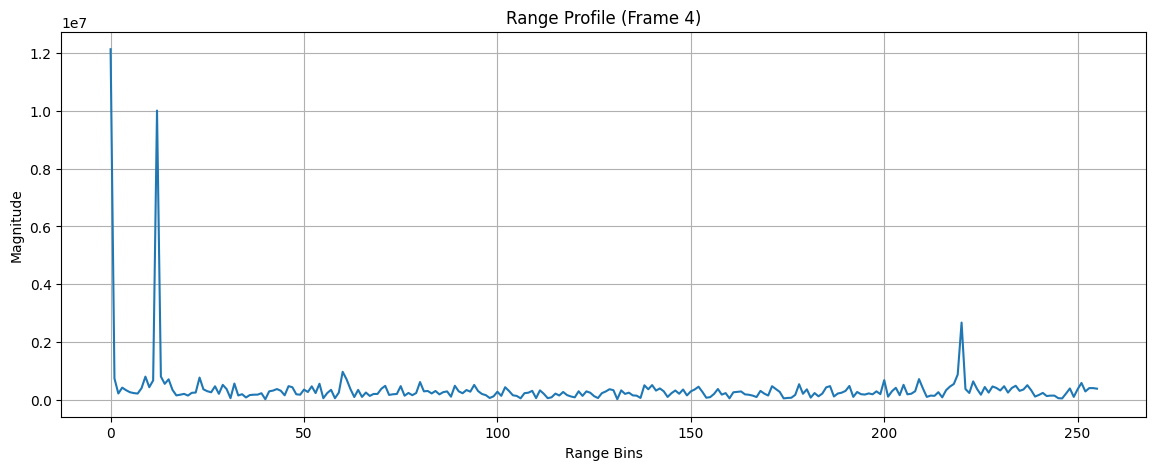

In [8]:
magnitude_data = np.abs(radar_cubes[4][0, 0, :])
# magnitude_db = 20 * np.log10(magnitude_data + 1e-10)
bins = np.arange(256)

plt.figure(figsize=(14, 5))
plt.plot(bins, magnitude_data)
plt.title("Range Profile (Frame 4)")
plt.xlabel("Range Bins")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

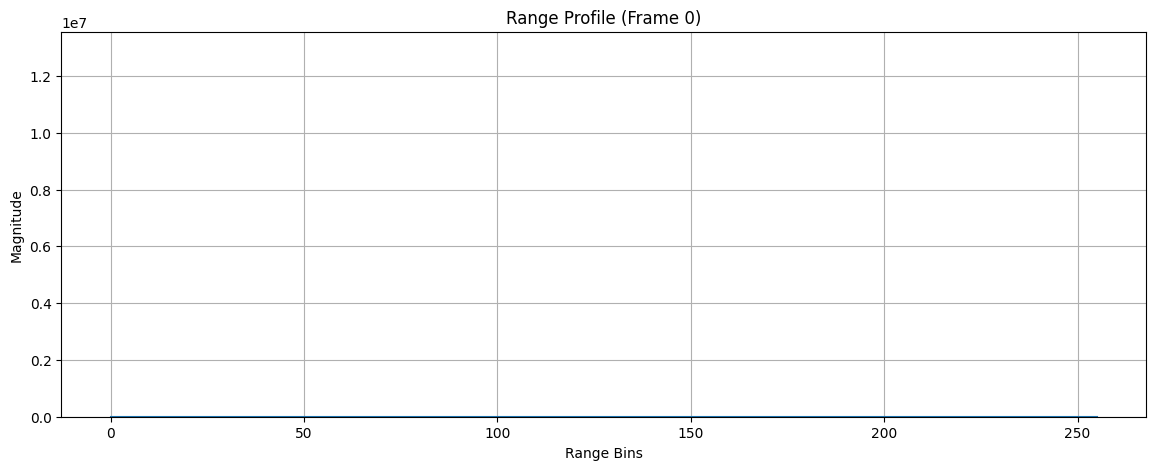

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
bins = np.arange(256)
global_max = np.max(np.abs(radar_cubes[:, 0, 0, :]))

magnitude_data_initial = np.abs(radar_cubes[0][0, 0, :])
line, = ax.plot(bins, magnitude_data_initial)

ax.set_xlabel("Range Bins")
ax.set_ylabel("Magnitude")
ax.grid(True)

ax.set_ylim(0, global_max * 1.1 + 1e-6)
def update(frame):
    magnitude_data = np.abs(radar_cubes[frame][0, 0, :])
    line.set_ydata(magnitude_data)
    ax.set_title(f"Range Profile (Frame {frame})")
    return [line]

ani = FuncAnimation(
    fig, 
    update, 
    frames=len(radar_cubes), 
    interval=50, 
    blit=False
)

ani.save("../Simulations/Radar/Phone_data_day02/Phone_Vibration_plots/Phone_static_2_Range_FFT_Data.gif", writer="pillow")

# Doppler FFT

In [11]:
det_matrices = []
aoa_inputs = []

for cube in radar_cubes:
    det_matrix, aoa_input = doppler_processing(
        cube,
        num_tx_antennas=3, 
        clutter_removal_enabled=False,
        interleaved=True, 
        window_type_2d=Window.HANNING,
        accumulate=True     
    )
    det_matrices.append(det_matrix)
    aoa_inputs.append(aoa_input)

det_matrices = np.array(det_matrices)
aoa_inputs = np.array(aoa_inputs)

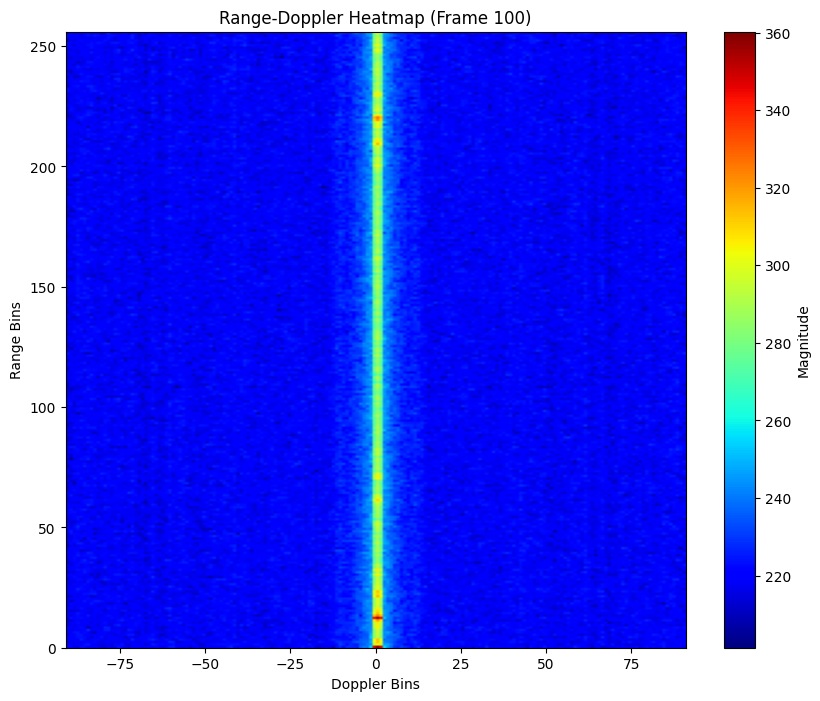

In [12]:
rd_map = det_matrices[100]
rd_map_shifted = np.fft.fftshift(rd_map, axes=1)

num_range_bins, num_doppler_bins = rd_map_shifted.shape
extent = [-num_doppler_bins // 2, num_doppler_bins // 2, 0, num_range_bins]

plt.figure(figsize=(10, 8))
plt.imshow(rd_map_shifted, aspect='auto', origin='lower', cmap='jet',extent=extent)
plt.title("Range-Doppler Heatmap (Frame 100)")
plt.xlabel("Doppler Bins")
plt.ylabel("Range Bins")
plt.colorbar(label="Magnitude")
plt.show()

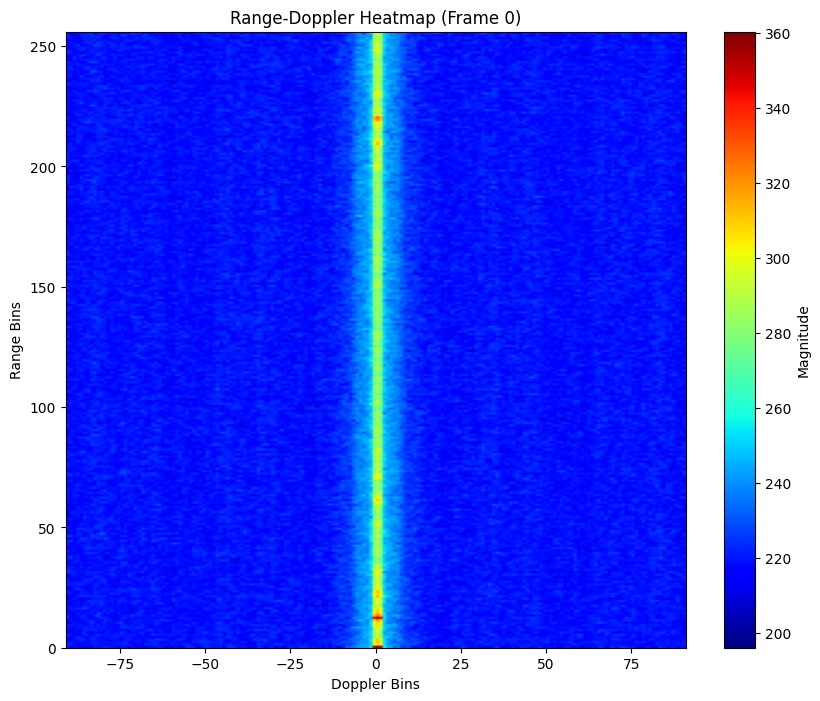

In [13]:
global_vmin = np.min(det_matrices)
global_vmax = np.max(det_matrices)

fig, ax = plt.subplots(figsize=(10, 8))
initial_map = np.fft.fftshift(det_matrices[0], axes=1)

im = ax.imshow(
    initial_map, 
    aspect='auto', 
    origin='lower', 
    cmap='jet', 
    extent=extent,
    vmin=global_vmin, 
    vmax=global_vmax
)

ax.set_xlabel("Doppler Bins")
ax.set_ylabel("Range Bins")
cbar = fig.colorbar(im, label="Magnitude")

def update(frame):
    rd_map_shifted = np.fft.fftshift(det_matrices[frame], axes=1)
    im.set_array(rd_map_shifted)
    ax.set_title(f"Range-Doppler Heatmap (Frame {frame})")
    return [im]

ani = FuncAnimation(
    fig, 
    update, 
    frames=len(det_matrices), 
    interval=50, 
    blit=False  
)

ani.save("../Simulations/Radar/Phone_data_day02/Phone_Vibration_plots/Phone_Static_Doppler_FFT_Data.gif", writer="pillow")

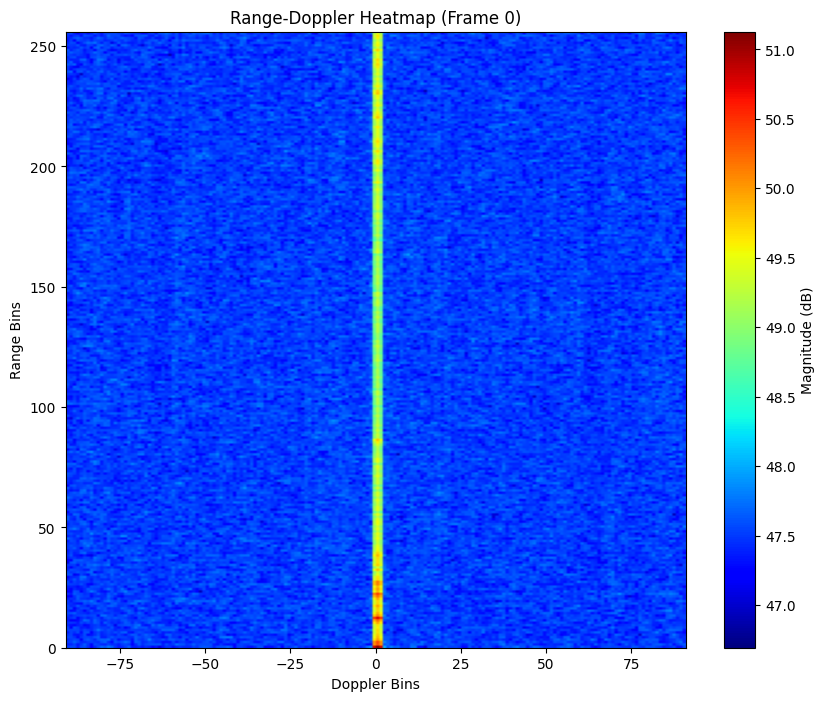

In [11]:
det_matrices_dB = 20 * np.log10(np.abs(det_matrices) + 1e-6)

global_vmin = np.min(det_matrices_dB)
global_vmax = np.max(det_matrices_dB)

global_vmin = max(global_vmin, global_vmax - 40)

fig, ax = plt.subplots(figsize=(10, 8))
initial_map = np.fft.fftshift(det_matrices_dB[0], axes=1)

im = ax.imshow(
    initial_map, 
    aspect='auto', 
    origin='lower', 
    cmap='jet', 
    extent=extent,
    vmin=global_vmin, 
    vmax=global_vmax
)

ax.set_xlabel("Doppler Bins")
ax.set_ylabel("Range Bins")
cbar = fig.colorbar(im, label="Magnitude (dB)")

def update(frame):
    rd_map_shifted = np.fft.fftshift(det_matrices_dB[frame], axes=1)
    im.set_array(rd_map_shifted)
    
    ax.set_title(f"Range-Doppler Heatmap (Frame {frame})")
    return [im]

ani = FuncAnimation(
    fig, 
    update, 
    frames=len(det_matrices_dB), 
    interval=50, 
    blit=False  
)

ani.save("../Simulations/Phone_Vibration_Doppler_FFT_Data.gif", writer="pillow")

# Azimuth FFT

In [12]:
aoa_data = aoa_inputs[100]
num_angle_bins = 182
azimuth_fft = np.fft.fft(aoa_data, n=num_angle_bins, axis=1)
azimuth_fft_shifted = np.fft.fftshift(azimuth_fft, axes=1)
range_angle_map = np.mean(np.abs(azimuth_fft_shifted), axis=2)
range_angle_map_t = range_angle_map.T

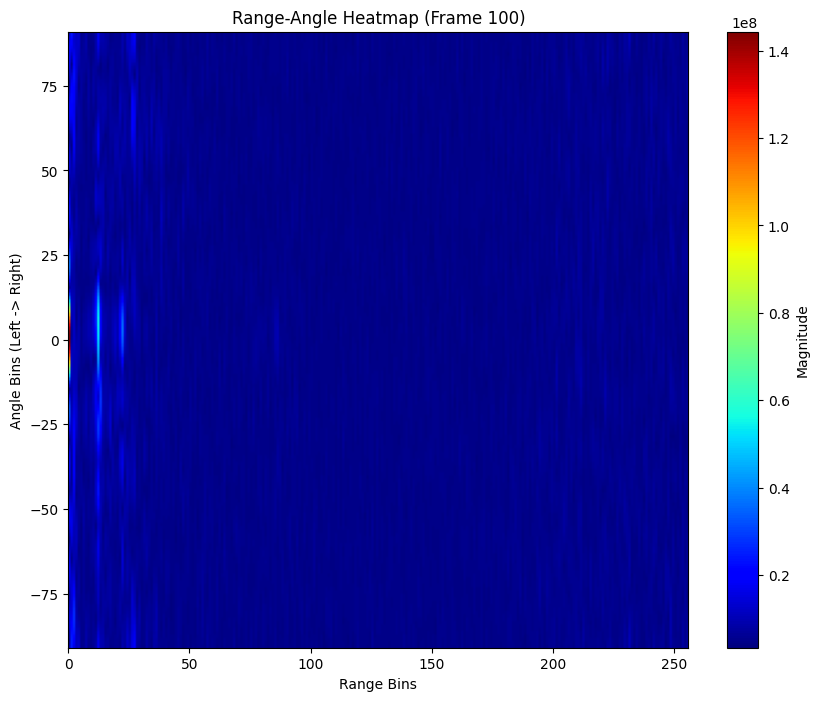

In [15]:
plt.figure(figsize=(10, 8))

num_range_bins, num_angle_bins = range_angle_map.shape
extent = [0, num_range_bins, -num_angle_bins // 2, num_angle_bins // 2]

plt.imshow(range_angle_map_t, aspect='auto', origin='lower', cmap='jet',extent=extent)
plt.title("Range-Angle Heatmap (Frame 100)")
plt.xlabel("Range Bins") 
plt.ylabel("Angle Bins (Left -> Right)") 
plt.colorbar(label="Magnitude")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))

azimuth_fft_initial=np.fft.fft(aoa_inputs[0],n=num_angle_bins,axis=1)
azimuth_fft_initial_shifted=np.fft.fftshift(azimuth_fft_initial,axes=1)
range_angle_map_initial = np.mean(np.abs(azimuth_fft_initial_shifted), axis=2)
range_angle_map_initial_t = range_angle_map_initial.T

num_range_bins, num_angle_bins = range_angle_map.shape
extent = [0, num_range_bins, -num_angle_bins // 2, num_angle_bins // 2]

im = ax.imshow(range_angle_map_initial_t, aspect='auto', origin='lower', cmap='jet',extent=extent)

ax.set_xlabel("Range Bins")
ax.set_ylabel("Angle Bins")
cbar = fig.colorbar(im, label="Magnitude")
def update(frame):
    azimuth_fft=np.fft.fft(aoa_inputs[frame],n=num_angle_bins,axis=1)
    azimuth_fft_shifted=np.fft.fftshift(azimuth_fft,axes=1)
    range_angle_map = np.mean(np.abs(azimuth_fft_shifted), axis=2)
    im.set_array(range_angle_map.T)
    # im.set_clim(vmin=np.min(rd_map_shifted), vmax=np.max(rd_map_shifted))
    ax.set_title(f"Azimuth Heatmap (Frame {frame})")
    return [im]

ani = FuncAnimation(
    fig, 
    update, 
    frames=len(aoa_inputs), 
    interval=50, 
    blit=False  
)

ani.save("../Simulations/Azimuth_FFT_Data_80.gif", writer="pillow")